In [1]:
import time

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import utils.data as datutils
import utils.file as futils

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Load data

# halos = futils.get_ahf_all()
# masses = np.array([(k, df['Mvir(4)'].loc[df['Redshift(0)'] == 0].values[0])
#                   for k, df in halos.items()])
# mm = np.median(masses[:, 1])
# lower_half_ids = masses[masses[:, 1] < mm][:, 0].astype(int)

mah_dict = futils.get_mah_all()
# mah_dict = {k: v for k, v in mah_dict.items() if k in lower_half_ids}
ma, _, aexp_bins = datutils.interp_ma(mah_dict)
am, mass_bins = datutils.build_am(ma=ma, scales=aexp_bins,
                                min_mass_bin=0.01, log_spacing=True)

stacked_ma = np.vstack([ma]*3)  # because we have 3 projections
stacked_am = np.vstack([am]*3)  # because we have 3 projections

halo_ids = np.array([int(k) for k in mah_dict.keys()])
m14 = futils.get_m14(halo_ids)
m14_stacked = np.hstack([m14['proj_x'], m14['proj_y'], m14['proj_y']])

dsdf = futils.get_ds(halo_ids)
# dsdf.reset_index(inplace=True)
dsdf.drop(columns=['eta_500[8]', 'delta_500[9]',
          'fm_500[10]', 'fm2_500[11]'], inplace=True)
smdf = futils.get_morphologies(halo_ids)
inner_df = futils.get_morphologies(halo_ids, 'r_0.03Mpc_205.csv')
iconc = inner_df['C']

/Users/kabelo/clusters/utils/data.py:342: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


In [3]:
smdf.columns

Index(['rhalf_circ', 'C', 'A', 'sersic_amplitude'], dtype='object')

In [5]:
sm_df_zx = futils.get_morph(
    'results/zx/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_xy = futils.get_morph(
    'results/xy/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_yz = futils.get_morph(
    'results/yz/rin50.0kpc_rout1.0Mpc_205.csv')

df1 = futils.get_morph('results/xy/r_0.03Mpc_205.csv')
df2 = futils.get_morph('results/yz/r_0.03Mpc_205.csv')
df3 = futils.get_morph('results/zx/r_0.03Mpc_205.csv')

TypeError: Index(...) must be called with a collection of some kind, 'results/zx/rin50.0kpc_rout1.0Mpc_205.csv' was passed

In [6]:
ordered_ids = [int(k) for k in mah_dict.keys()]

def align_df(df, ids):
    # ensure ID is index if present as column, then reindex in same order and reset index
    if 'ID' in df.columns:
        df = df.set_index('ID')
    
    df = df.reindex(ids)
    return df.reset_index(drop=True)

# reindex all per-halo tables to the same ordered_ids
m14 = align_df(m14, ordered_ids)
sm_df_xy = align_df(sm_df_xy, ordered_ids)
sm_df_yz = align_df(sm_df_yz, ordered_ids)
sm_df_zx = align_df(sm_df_zx, ordered_ids)
dsdf = align_df(dsdf, ordered_ids)

# rebuild stacked arrays after alignment
m14_stacked = np.hstack([m14['proj_x'], m14['proj_y'], m14['proj_z']])
stacked_ma = np.vstack([ma]*3)
stacked_am = np.vstack([am]*3)

def get_reindexed_series(df, ids, col='C'):
    if 'ID' in df.columns:
        base = df.set_index('ID')
    elif df.index.name == 'ID':
        base = df
    else:
        # try resetting unnamed index to locate an ID column; else raise
        tmp = df.reset_index()
        if 'ID' in tmp.columns:
            base = tmp.set_index('ID')
        else:
            raise KeyError("DataFrame has no 'ID' column and index.name != 'ID'")
    return base.reindex(ids)[col].reset_index(drop=True)

df1_c = get_reindexed_series(df1, ordered_ids, col='C')
df2_c = get_reindexed_series(df2, ordered_ids, col='C')
df3_c = get_reindexed_series(df3, ordered_ids, col='C')

# stacked iconc length should be 3 * n_halos and match m14_stacked order
iconc = pd.concat([df1_c, df2_c, df3_c], axis=0).reset_index(drop=True)
assert iconc.shape[0] == 3 * len(ordered_ids), "iconc stacked length mismatch"

n_halos = len(am)
assert sm_df_xy.shape[0] == n_halos and sm_df_yz.shape[0] == n_halos and sm_df_zx.shape[0] == n_halos, "per-projection DF lengths mismatch"
assert m14_stacked.shape[0] == 3 * n_halos and stacked_am.shape[0] == 3 * n_halos, "stacked lengths mismatch"

print("n_halos:", n_halos, "m14_stacked:", m14_stacked.shape, "stacked_am:", stacked_am.shape)

NameError: name 'sm_df_xy' is not defined

In [6]:
np.shape(smdf.to_numpy())

(615, 4)

In [3]:
start = time.time()
state = 5
n_halos = len(am)
halo_idx = np.arange(n_halos)
train_idx, test_idx = train_test_split(
    halo_idx, test_size=0.25, random_state=state)

x = np.vstack((dsdf.to_numpy().T, m14.to_numpy().T)).T
y = am
x_train = x[train_idx]
x_test = x[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]


# # Stack indices across all 3 projections
# stacked_train_idx = np.concatenate(
#     [train_idx, train_idx + n_halos, train_idx + 2*n_halos])
# stacked_test_idx = np.concatenate(
#     [test_idx,  test_idx + n_halos, test_idx + 2*n_halos])

# # x_train = np.vstack([smdf_proj.to_numpy()[train_idx]
# #                     for smdf_proj in [sm_df_xy, sm_df_yz, sm_df_zx]])

# x_train = np.concatenate([smdf.to_numpy()[stacked_train_idx],
#                           m14_stacked[:, None][stacked_train_idx],
#                           iconc.to_numpy()[:, None][stacked_train_idx]], axis=1)

# # x_test = np.vstack([smdf_proj.to_numpy()[test_idx]
# #                    for smdf_proj in [sm_df_xy, sm_df_yz, sm_df_zx]])
# x_test = np.concatenate([smdf.to_numpy()[stacked_test_idx],
#                          m14_stacked[:, None][stacked_test_idx],
#                          iconc.to_numpy()[:, None][stacked_test_idx]], axis=1)

# y_train = stacked_am[stacked_train_idx]
# y_test = stacked_am[stacked_test_idx]

m = 0.5
mhalf_indx = np.argmin(np.abs(mass_bins-m))
a50_test = y_test[:, mhalf_indx]
a50_train = y_train[:, mhalf_indx]


qt = QuantileTransformer(output_distribution='normal', random_state=state)
x_train_qt = qt.fit_transform(x_train)
x_test_qt = qt.transform(x_test) # fit only on train

model = xgb.XGBRegressor(random_state=state)
parameter_space = {'learning_rate': [0.01, 0.05, 0.1],
                   'max_depth': [1, 2, 3],
                   'n_estimators': [100, 250, 500]}

reg = GridSearchCV(model, parameter_space, cv=5, scoring='r2', verbose=1)
reg.fit(x_train_qt, a50_train)
regressor = reg.best_estimator_

print(reg.best_params_)
print('  ... training took %.2f seconds' % (time.time() - start))
preds = regressor.predict(x_test_qt)
residuals = preds - a50_test
r2 = r2_score(a50_test, preds)
print(f'r2 : {r2}')
print(f'rmse : {np.sqrt(mean_squared_error(a50_test, preds))}')
# baseline: predict train mean
mean_pred = np.full_like(a50_test, a50_train.mean())
print('baseline mean r2:', r2_score(a50_test, mean_pred))

/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (153). n_quantiles is set to n_samples.
  warnings.warn(


Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 500}
  ... training took 17.79 seconds
r2 : 0.5654499183210684
rmse : 0.07343750458644707
baseline mean r2: -0.0008539850541140481


In [8]:
dsdf.columns

Index(['eta_200[3]', 'delta_200[4]', 'fm_200[5]', 'fm2_200[6]'], dtype='object')

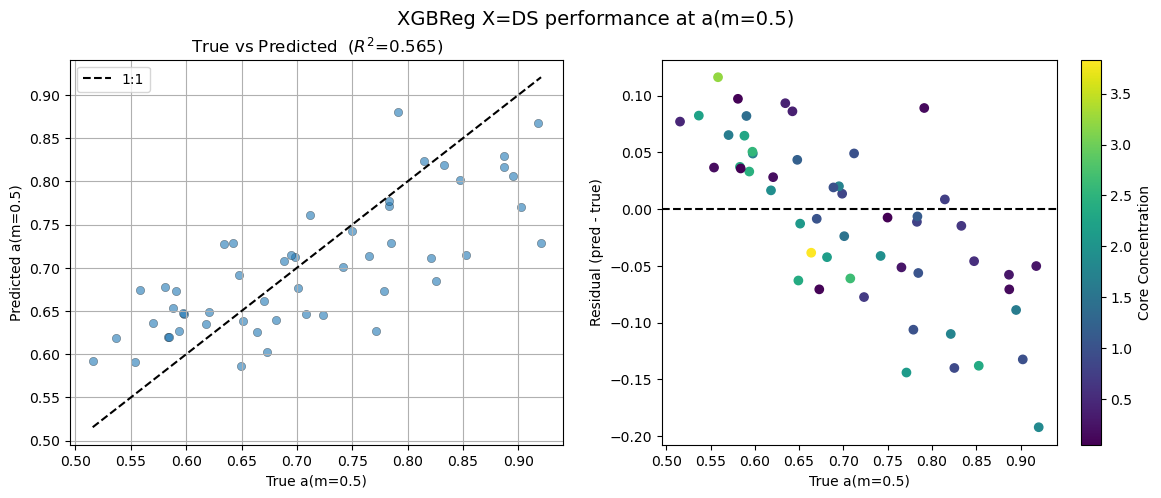

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

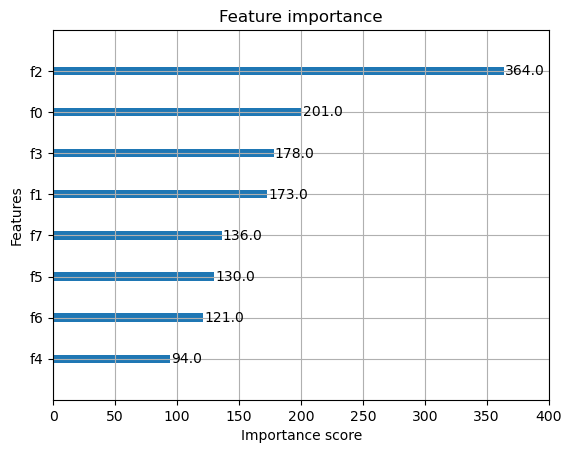

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'XGBReg X=DS performance at a(m={m})', fontsize=14)

# true vs predicted
axs[0].scatter(a50_test, preds, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(a50_test.min(), preds.min()), max(a50_test.max(), preds.max())]
axs[0].plot(lims, lims, 'k--', label='1:1')
axs[0].set_xlabel(f'True a(m={m})')
axs[0].set_ylabel(f'Predicted a(m={m})')
axs[0].set_title(f'True vs Predicted  ($R^2$={r2:.3f})')
axs[0].legend()
axs[0].grid()

# # Residual histogram
# axs[1].hist(residuals, bins=20, edgecolor='k', alpha=0.7)
# axs[1].axvline(0, color='k', linestyle='--')
# axs[1].axvline(residuals.mean(), color='red', linestyle='--',
#                label=f'Mean={residuals.mean():.3f}')
# axs[1].set_xlabel('Residual (pred - true)')
# axs[1].set_ylabel('Count')
# axs[1].set_title(rf'Residuals ($\sigma$={residuals.std():.3f})')
# axs[1].legend()
# axs[1].grid()

# these names are NOT always correct, just for quick plotting
x_test_rh = x_test[:, 0]
x_test_conc = x_test[:, 1]
x_test_A = x_test[:, 2]
x_test_sa = x_test[:, 3]
x_test_m14 = x_test[:, 4]
x_test_cc = x_test[:, 5]

sc = axs[1].scatter(a50_test, residuals, c=x_test_cc)   
axs[1].axhline(0, color='k', linestyle='--')
axs[1].set_xlabel(f'True a(m={m})')
axs[1].set_ylabel('Residual (pred - true)')
plt.colorbar(sc, ax=axs[1], label='Core Concentration')

plt.show()

xgb.plot_importance(regressor)